# Proyecto 3 — ABC Corporation
## Análisis de Datos para Retener y Potenciar Empleados

| | |
|---|---|
| **Dataset** | `hr.csv` — 1.474 empleados × 35 variables |
| **Variable objetivo** | `Attrition` (1 = abandona / 0 = se queda) |
| **Objetivo** | Identificar factores que influyen en el abandono de empleados |

---
## Índice
- [🔍 Fase 1 — EDA](#fase1)
- [🔧 Fase 2 — Transformación](#fase2)
- [📊 Fase 3 — Visualización](#fase3)

---
<a id='fase1'></a>
# 🔍 FASE 1 — Análisis Exploratorio de Datos (EDA)
Antes de transformar nada, necesitamos entender qué datos tenemos, qué calidad tienen y qué problemas hay que resolver.

## CELDA 1 — Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print('Librerías cargadas correctamente!')

Librerías cargadas correctamente!


## CELDA 2 — Estilo y colores del proyecto

In [2]:
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

VERDE = '#2E7D32'   # empleados que SE QUEDAN
ROJO  = '#C62828'   # empleados que ABANDONAN
print('Colores: VERDE = se queda | ROJO = abandona')

Colores: VERDE = se queda | ROJO = abandona


## CELDA 3 — Carga del dataset y comprobación de integridad

In [3]:
df_original = pd.read_csv('hr.csv')
df = df_original.copy()

print(f'¿Filas correctas?   {"Sí" if df.shape[0] == 1474 else "No"} ({df.shape[0]} filas)')
print(f'¿Columnas correctas? {"Sí" if df.shape[1] == 35 else "No"} ({df.shape[1]} columnas)')
print(f'Total celdas con datos : {df.notnull().sum().sum()}')
print(f'Total celdas vacías    : {df.isnull().sum().sum()}')
print()
df.head()

¿Filas correctas?   Sí (1474 filas)
¿Columnas correctas? Sí (35 columnas)
Total celdas con datos : 50694
Total celdas vacías    : 896



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,sALES eXECUTIVE,4.0,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,rESEARCH sCIENTIST,2.0,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0
2,37.0,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,lABORATORY tECHNICIAN,3.0,Single,2090.0,2396,6,Y,Yes,15,3,2,NaN,0,7,3.0,3,0,0,0,0.0
3,33.0,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,rESEARCH sCIENTIST,3.0,Married,2909.0,23159,1,Y,Yes,11,3,3,80.0,0,8,3.0,3,8,7,3,0.0
4,27.0,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,lABORATORY tECHNICIAN,2.0,Married,3468.0,16632,9,Y,No,12,3,4,80.0,1,6,3.0,3,2,2,2,2.0


## CELDA 4 — Tipos de datos

In [4]:
print('TIPOS DE DATOS:')
print(df.dtypes.to_string())
print()
print(f'Columnas numéricas  : {df.select_dtypes(include="number").shape[1]}')
print(f'Columnas categóricas: {df.select_dtypes(include="object").shape[1]}')
print()
print('Columnas float64 (deberían ser int tras imputar nulos):')
print(df.select_dtypes(include='float64').columns.tolist())

TIPOS DE DATOS:
Age                         float64
Attrition                       str
BusinessTravel                  str
DailyRate                     int64
Department                      str
DistanceFromHome              int64
Education                     int64
EducationField                  str
EmployeeCount                 int64
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                          str
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                         str
JobSatisfaction             float64
MaritalStatus                   str
MonthlyIncome               float64
MonthlyRate                   int64
NumCompaniesWorked            int64
Over18                          str
OverTime                        str
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StandardHours               float64
StockOptionL

## CELDA 5 — Estadísticas descriptivas numéricas

In [5]:
# count < 1474 → esa columna tiene nulos
df.describe().round(2)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1401.00,1474.00,1474.0,1474.00,1474.0,1474.00,1474.00,1474.00,1474.00,1474.00,1445.00,1460.00,1474.00,1474.00,1474.00,1474.00,1474.00,1310.0,1474.00,1474.00,1386.0,1474.00,1474.00,1474.00,1474.00,1326.00
mean,36.94,802.70,9.2,2.91,1.0,1024.47,2.72,65.89,2.73,2.06,2.73,6497.45,14328.61,2.69,15.21,3.15,2.71,80.0,0.79,11.27,2.8,2.76,7.00,4.22,2.18,4.06
std,9.11,403.54,8.1,1.02,0.0,602.42,1.09,20.31,0.71,1.11,1.11,4706.06,7120.23,2.50,3.66,0.36,1.08,0.0,0.85,7.79,1.3,0.71,6.12,3.62,3.22,3.52
min,18.00,102.00,1.0,1.00,1.0,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,2094.00,0.00,11.00,3.00,1.00,80.0,0.00,0.00,0.0,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.0,2.00,1.0,488.75,2.00,48.00,2.00,1.00,2.00,2909.00,8054.50,1.00,12.00,3.00,2.00,80.0,0.00,6.00,2.0,2.00,3.00,2.00,0.00,2.00
50%,36.00,803.00,7.0,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,3.00,4907.00,14248.50,2.00,14.00,3.00,3.00,80.0,1.00,10.00,3.0,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.0,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,4.00,8377.00,20465.75,4.00,18.00,3.00,4.00,80.0,1.00,15.00,3.0,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.0,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,4.00,19999.00,26999.00,9.00,25.00,4.00,4.00,80.0,3.00,40.00,6.0,4.00,40.00,18.00,15.00,17.00


## CELDA 6 — Estadísticas descriptivas categóricas

In [6]:
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1474,1357,1445,1416,1474,1474,1342,1474,1430
unique,2,3,3,6,2,9,4,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,sALES eXECUTIVE,Married,Y,No
freq,1236,955,941,582,885,327,604,1474,1025


## CELDA 7 — Análisis de nulos

In [7]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
tabla_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': pct})
tabla_nulos = tabla_nulos[tabla_nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False)

print(f'Columnas con nulos: {len(tabla_nulos)} de {df.shape[1]}')
print()
print(tabla_nulos.to_string())

Columnas con nulos: 11 de 35

                       Nulos  % Nulos
StandardHours            164    11.13
YearsWithCurrManager     148    10.04
MaritalStatus            132     8.96
BusinessTravel           117     7.94
TrainingTimesLastYear     88     5.97
Age                       73     4.95
EducationField            58     3.93
OverTime                  44     2.99
Department                29     1.97
JobSatisfaction           29     1.97
MonthlyIncome             14     0.95


### 📋 Tabla resumen de nulos y estrategia de imputación

| Columna | Nulos | % | Tipo | Estrategia |
|---------|-------|---|------|------------|
| StandardHours | 164 | 11.13% | Numérica | **Eliminar** — columna constante (siempre 80) |
| YearsWithCurrManager | 148 | 10.04% | Numérica | Mediana |
| MaritalStatus | 132 | 8.96% | Categórica | Moda |
| BusinessTravel | 117 | 7.94% | Categórica | Moda |
| TrainingTimesLastYear | 88 | 5.97% | Numérica | Mediana |
| Age | 73 | 4.95% | Numérica | Mediana |
| EducationField | 58 | 3.93% | Categórica | Moda |
| OverTime | 44 | 2.99% | Categórica | Moda |
| Department | 29 | 1.97% | Categórica | Moda |
| JobSatisfaction | 29 | 1.97% | Numérica | Mediana |
| MonthlyIncome | 14 | 0.95% | Numérica | Mediana |

## CELDA 8 — Duplicados y columnas constantes

In [8]:
print(f'Filas duplicadas: {df.duplicated().sum()}')
print()
print('Columnas con un solo valor único (sin varianza):')
for col in df.columns:
    unicos = df[col].dropna().unique()
    if len(unicos) == 1:
        print(f'  {col} -> siempre vale: {unicos[0]}')

Filas duplicadas: 4

Columnas con un solo valor único (sin varianza):
  EmployeeCount -> siempre vale: 1
  Over18 -> siempre vale: Y
  StandardHours -> siempre vale: 80.0


## CELDA 9 — Calidad de variables categóricas (detección de typos)

In [9]:
columnas_cat = ['JobRole', 'Department', 'Gender', 'MaritalStatus', 'OverTime', 'BusinessTravel']

for col in columnas_cat:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False))
    print()

--- JobRole ---
JobRole
sALES eXECUTIVE               327
rESEARCH sCIENTIST            293
lABORATORY tECHNICIAN         259
mANUFACTURING dIRECTOR        146
hEALTHCARE rEPRESENTATIVE     131
mANAGER                       102
sALES rEPRESENTATIVE           83
rESEARCH dIRECTOR              80
hUMAN rESOURCES                53
Name: count, dtype: int64

--- Department ---
Department
Research & Development    941
Sales                     440
Human Resources            64
NaN                        29
Name: count, dtype: int64

--- Gender ---
Gender
Male      885
Female    589
Name: count, dtype: int64

--- MaritalStatus ---
MaritalStatus
Married     604
Single      437
Divorced    298
NaN         132
Marreid       3
Name: count, dtype: int64

--- OverTime ---
OverTime
No     1025
Yes     405
NaN      44
Name: count, dtype: int64

--- BusinessTravel ---
BusinessTravel
Travel_Rarely        955
Travel_Frequently    263
Non-Travel           139
NaN                  117
Name: count, dtype:

**🔍 Hallazgos detectados:**
- **`JobRole`** → Formato incorrecto (`' sALES eXECUTIVE '`) — espacios y mayúsculas mezcladas → limpiar con `str.strip().str.title()`
- **`MaritalStatus`** → Typo `'Marreid'` (3 casos) → corregir a `'Married'`. Además 132 nulos → imputar con moda
- **`Department`** → 29 nulos → imputar con moda
- **`OverTime`** → 44 nulos → imputar con moda
- **`BusinessTravel`** → 117 nulos → imputar con moda
- **`Gender`** → Sin problemas ✅

## CELDA 10 — Variable objetivo: Attrition

In [10]:
conteo     = df['Attrition'].value_counts()
porcentaje = (df['Attrition'].value_counts(normalize=True) * 100).round(2)

print('DISTRIBUCIÓN DE ATTRITION:')
print(f'  Se queda (No) : {conteo["No"]}  empleados -> {porcentaje["No"]}%')
print(f'  Abandona (Yes): {conteo["Yes"]} empleados -> {porcentaje["Yes"]}%')
print()
print('⚠️  Dataset desbalanceado: ratio 5:1 (importante para modelado)')

DISTRIBUCIÓN DE ATTRITION:
  Se queda (No) : 1236  empleados -> 83.85%
  Abandona (Yes): 238 empleados -> 16.15%

⚠️  Dataset desbalanceado: ratio 5:1 (importante para modelado)


## CELDA 11 — Gráfico: distribución de Attrition

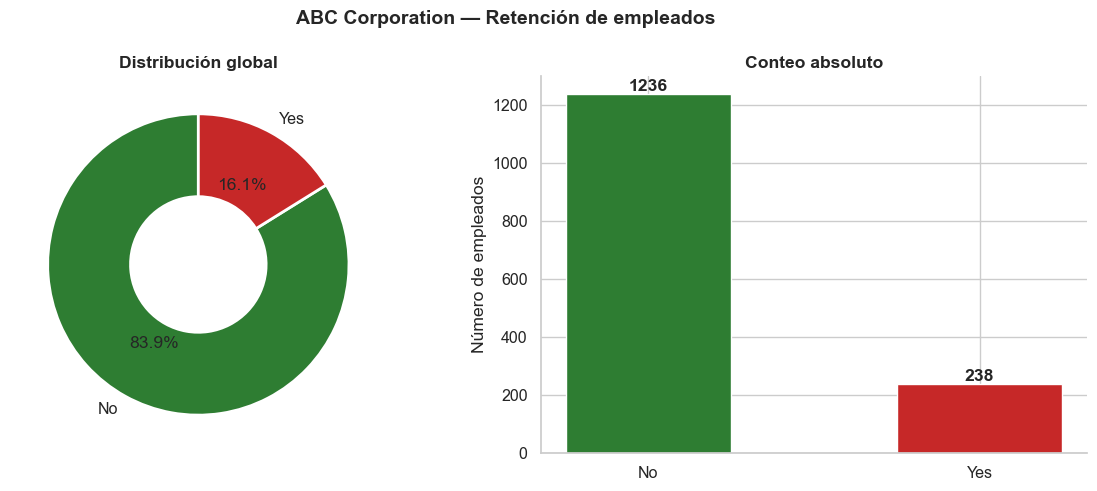

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(conteo, labels=conteo.index, colors=[VERDE, ROJO],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
axes[0].set_title('Distribución global', fontweight='bold')

barras = axes[1].bar(conteo.index, conteo.values,
                      color=[VERDE, ROJO], edgecolor='white', width=0.5)
for b in barras:
    h = b.get_height()
    axes[1].text(b.get_x() + b.get_width()/2, h+10, str(int(h)),
                 ha='center', fontweight='bold')
axes[1].set_title('Conteo absoluto', fontweight='bold')
axes[1].set_ylabel('Número de empleados')

plt.suptitle('ABC Corporation — Retención de empleados', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## CELDA 12 — Attrition por departamento

Attrition                  No    Yes
Department                          
Human Resources         79.69  20.31
Research & Development  86.61  13.39
Sales                   79.77  20.23


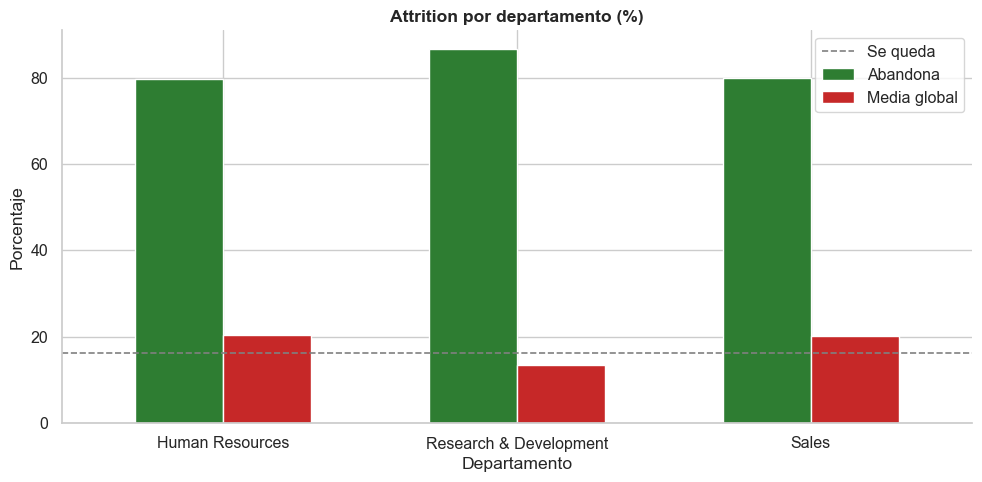

In [12]:
agrupado = df.groupby('Department')['Attrition'].value_counts(normalize=True) * 100
tabla = agrupado.unstack().fillna(0).round(2)
print(tabla)

tabla[['No','Yes']].plot(kind='bar', color=[VERDE, ROJO],
                          edgecolor='white', width=0.6, figsize=(10,5))
plt.axhline(y=porcentaje['Yes'], color='gray', linestyle='--', linewidth=1.2,
            label=f'Media global ({porcentaje["Yes"]}%)')
plt.title('Attrition por departamento (%)', fontweight='bold')
plt.xlabel('Departamento')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.legend(['Se queda','Abandona','Media global'])
plt.tight_layout()
plt.show()

## CELDA 13 — Attrition por JobRole

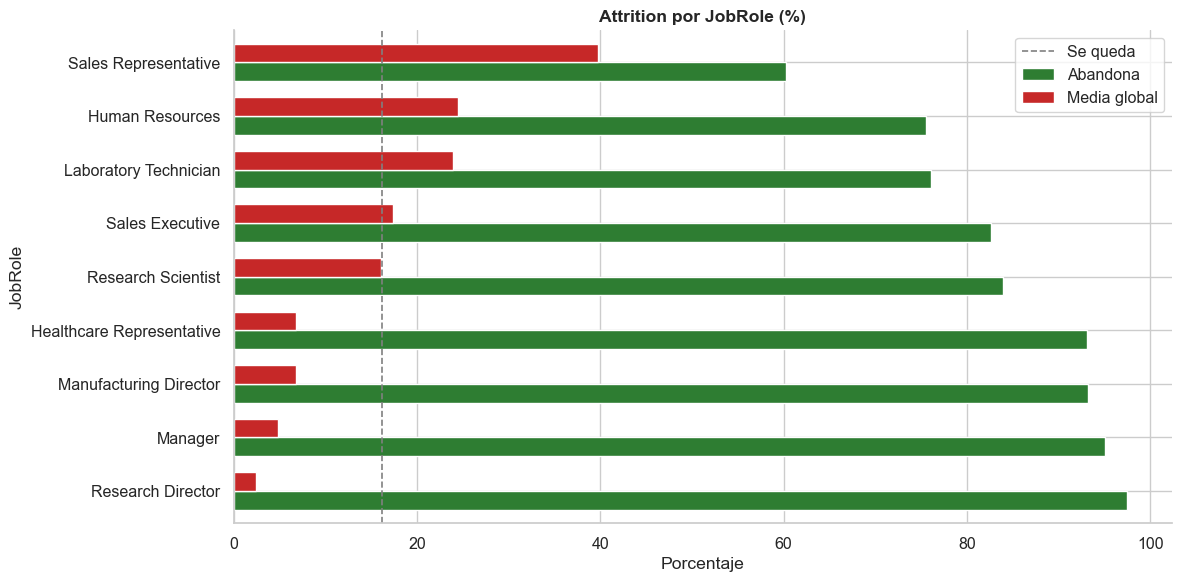

In [13]:
df_viz = df.copy()
df_viz['JobRole'] = df_viz['JobRole'].str.strip().str.title()

agrupado = df_viz.groupby('JobRole')['Attrition'].value_counts(normalize=True) * 100
tabla = agrupado.unstack().fillna(0).round(2).sort_values('Yes', ascending=True)

tabla[['No','Yes']].plot(kind='barh', color=[VERDE, ROJO],
                          edgecolor='white', width=0.7, figsize=(12,6))
plt.axvline(x=porcentaje['Yes'], color='gray', linestyle='--', linewidth=1.2,
            label=f'Media global ({porcentaje["Yes"]}%)')
plt.title('Attrition por JobRole (%)', fontweight='bold')
plt.xlabel('Porcentaje')
plt.legend(['Se queda','Abandona','Media global'])
plt.tight_layout()
plt.show()

## CELDA 14 — Overtime vs Attrition

Attrition     No    Yes
OverTime               
No         89.76  10.24
Yes        69.14  30.86


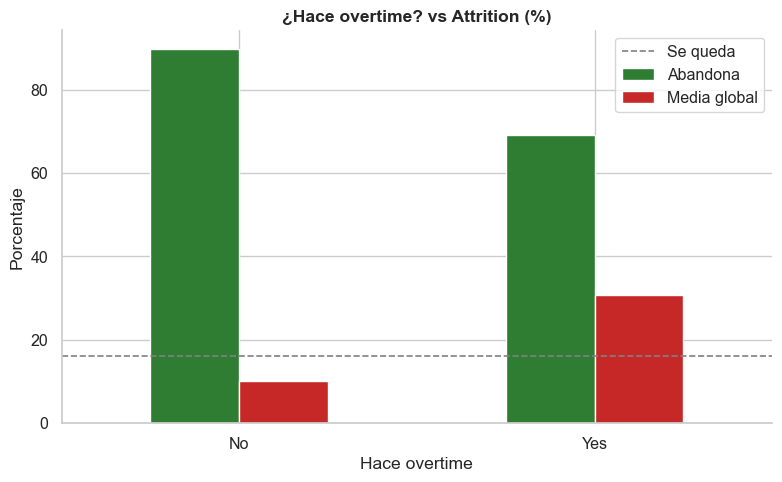

In [14]:
agrupado = df.groupby('OverTime')['Attrition'].value_counts(normalize=True) * 100
tabla = agrupado.unstack().fillna(0).round(2)
print(tabla)

fig, ax = plt.subplots(figsize=(8,5))
tabla[['No','Yes']].plot(kind='bar', color=[VERDE, ROJO],
                          edgecolor='white', width=0.5, ax=ax)
plt.axhline(y=porcentaje['Yes'], color='gray', linestyle='--', linewidth=1.2)
plt.title('¿Hace overtime? vs Attrition (%)', fontweight='bold')
plt.xlabel('Hace overtime')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.legend(['Se queda','Abandona','Media global'])
plt.tight_layout()
plt.show()

## CELDA 15 — Salario vs Attrition

Salario medio (se queda): $6,833
Salario medio (abandona): $4,741
Diferencia              : $2,092/mes


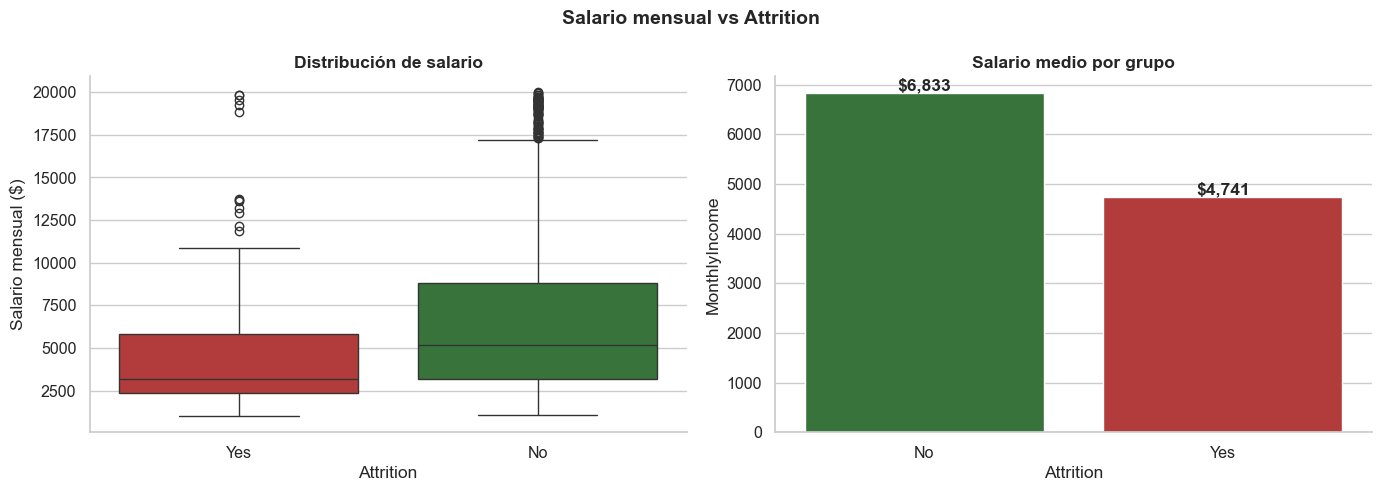

In [15]:
salario_no  = df[df['Attrition']=='No']['MonthlyIncome'].mean()
salario_yes = df[df['Attrition']=='Yes']['MonthlyIncome'].mean()
print(f'Salario medio (se queda): ${salario_no:,.0f}')
print(f'Salario medio (abandona): ${salario_yes:,.0f}')
print(f'Diferencia              : ${salario_no-salario_yes:,.0f}/mes')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            palette={'No': VERDE, 'Yes': ROJO}, ax=axes[0])
axes[0].set_title('Distribución de salario', fontweight='bold')
axes[0].set_ylabel('Salario mensual ($)')

medias = df.groupby('Attrition')['MonthlyIncome'].mean().reset_index()
sns.barplot(data=medias, x='Attrition', y='MonthlyIncome',
            palette={'No': VERDE, 'Yes': ROJO}, ax=axes[1])
axes[1].set_title('Salario medio por grupo', fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f'${p.get_height():,.0f}',
                     (p.get_x()+p.get_width()/2, p.get_height()+50),
                     ha='center', fontweight='bold')

plt.suptitle('Salario mensual vs Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## CELDA 16 — Satisfacción vs Attrition

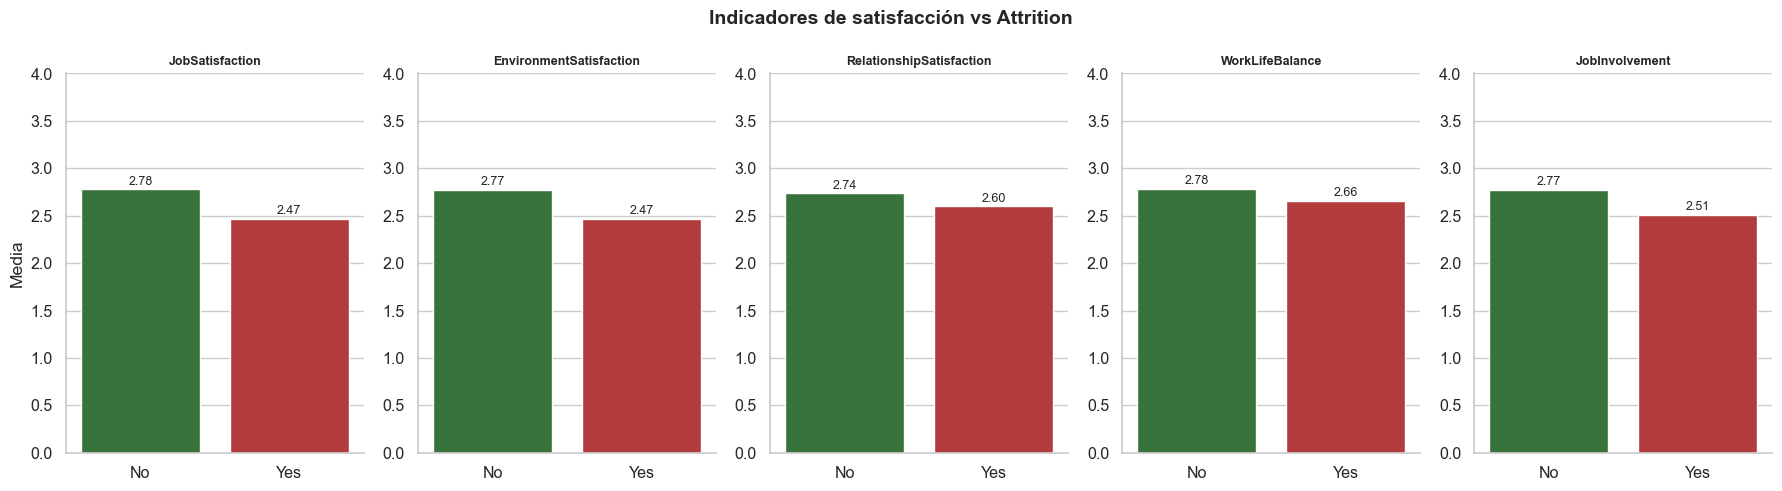

In [16]:
cols_sat = ['JobSatisfaction','EnvironmentSatisfaction',
            'RelationshipSatisfaction','WorkLifeBalance','JobInvolvement']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(cols_sat):
    medias = df.groupby('Attrition')[col].mean().reset_index()
    sns.barplot(data=medias, x='Attrition', y=col,
                palette={'No': VERDE, 'Yes': ROJO}, ax=axes[i])
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Media' if i==0 else '')
    axes[i].set_ylim(0, 4)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2f}',
                         (p.get_x()+p.get_width()/2, p.get_height()+0.05),
                         ha='center', fontsize=9)

plt.suptitle('Indicadores de satisfacción vs Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## CELDA 17 — Distribuciones numéricas por Attrition

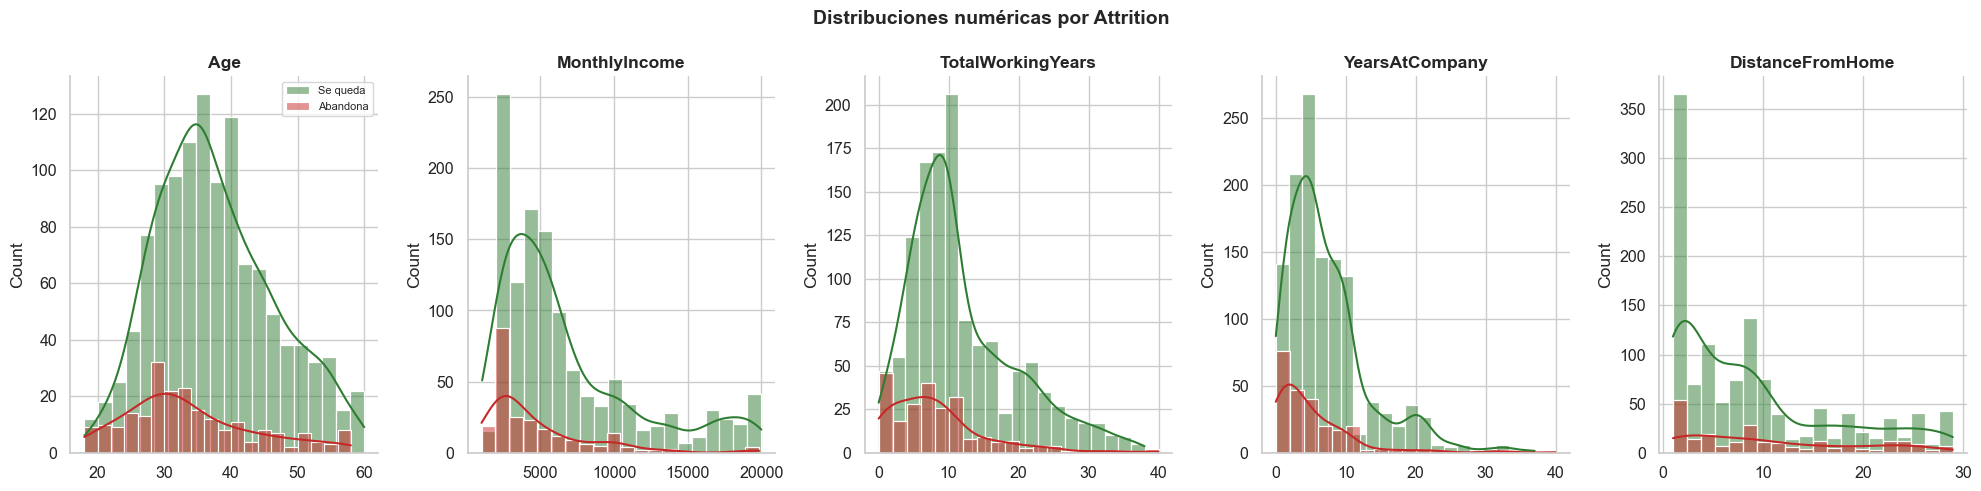

In [17]:
vars_num = ['Age','MonthlyIncome','TotalWorkingYears','YearsAtCompany','DistanceFromHome']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(vars_num):
    sns.histplot(data=df[df['Attrition']=='No'], x=col, bins=20, kde=True,
                 color=VERDE, alpha=0.5, ax=axes[i], label='Se queda')
    sns.histplot(data=df[df['Attrition']=='Yes'], x=col, bins=20, kde=True,
                 color=ROJO, alpha=0.5, ax=axes[i], label='Abandona')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Distribuciones numéricas por Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## CELDA 18 — Matriz de correlación

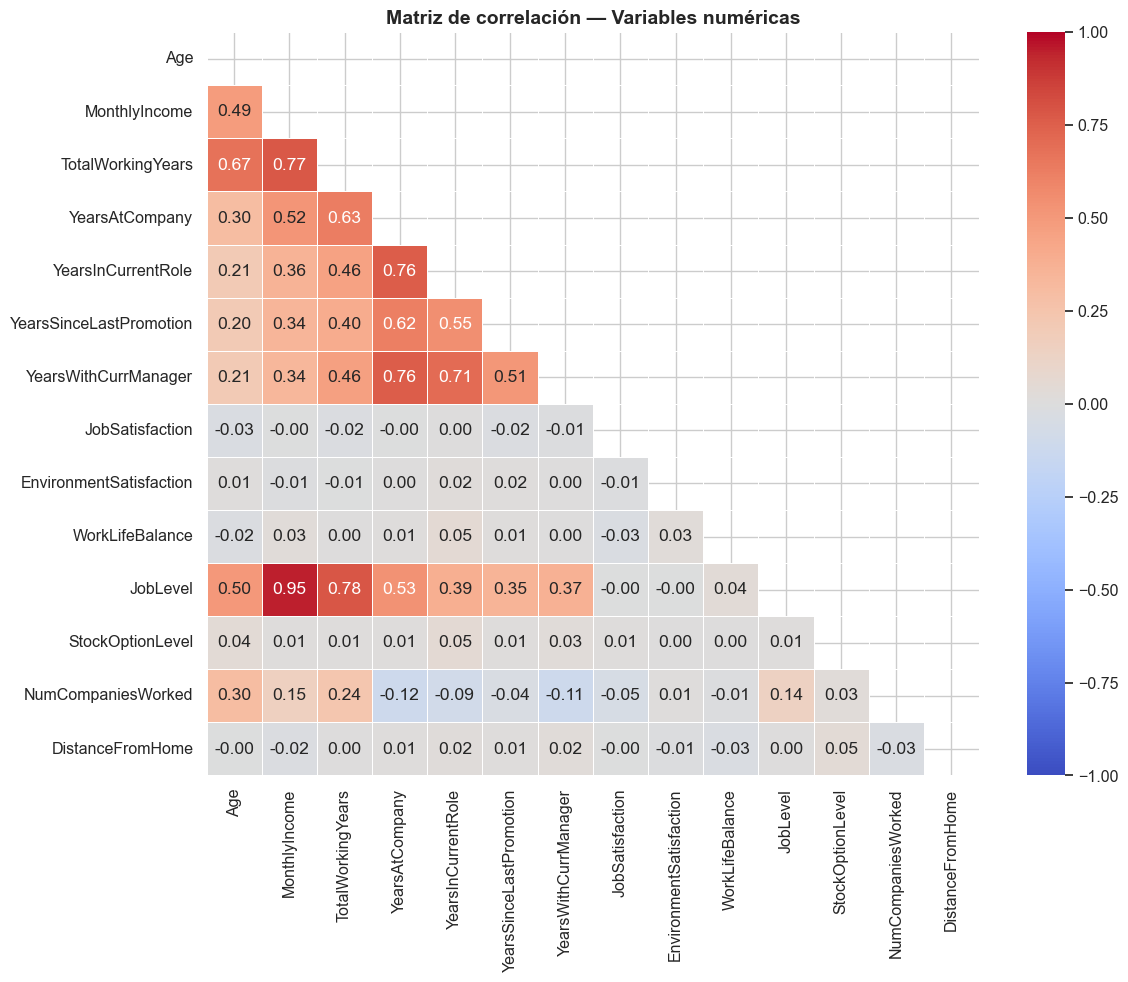

In [18]:
cols_corr = ['Age','MonthlyIncome','TotalWorkingYears','YearsAtCompany',
             'YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager',
             'JobSatisfaction','EnvironmentSatisfaction','WorkLifeBalance',
             'JobLevel','StockOptionLevel','NumCompaniesWorked','DistanceFromHome']

corr = df[cols_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True,
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de correlación — Variables numéricas', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## CELDA 19 — Resumen ejecutivo Fase 1

In [19]:
print('=' * 58)
print('  RESUMEN EDA — ABC CORPORATION')
print('=' * 58)
print(f'  Total empleados          : {len(df)}')
print(f'  Variables analizadas     : {df.shape[1]}')
print(f'  Tasa de attrition        : {porcentaje["Yes"]}%')
print(f'  Empleados que abandonan  : {conteo["Yes"]}')
print(f'  Columnas con nulos       : 11 de 35')
print(f'  Filas duplicadas         : {df.duplicated().sum()}')
print(f'  Columnas sin varianza    : 3')
print(f'  Typos detectados         : JobRole, MaritalStatus')
print()
print('HALLAZGOS PRINCIPALES:')
print('  1. 1 de cada 6 empleados abandona (16.15%)')
print('  2. Sales Representatives: 40% de abandono — rol más crítico')
print('  3. Hacer overtime TRIPLICA el riesgo: 10% -> 31%')
print('  4. Los que abandonan cobran $2.000/mes menos')
print('  5. Empleados solteros abandonan más que casados')
print('  6. JobLevel y MonthlyIncome tienen correlación 0.95')
print()
print('ACCIONES PARA FASE 2:')
print('  - Eliminar 4 duplicados')
print('  - Eliminar 3 columnas constantes')
print('  - Limpiar JobRole (texto corrupto)')
print('  - Corregir typo MaritalStatus')
print('  - Imputar nulos (mediana/moda)')
print('  - Corregir tipos float -> int')
print('  - Codificar Attrition y OverTime a 0/1')
print('  - Crear columnas nuevas con apply()')

  RESUMEN EDA — ABC CORPORATION
  Total empleados          : 1474
  Variables analizadas     : 35
  Tasa de attrition        : 16.15%
  Empleados que abandonan  : 238
  Columnas con nulos       : 11 de 35
  Filas duplicadas         : 4
  Columnas sin varianza    : 3
  Typos detectados         : JobRole, MaritalStatus

HALLAZGOS PRINCIPALES:
  1. 1 de cada 6 empleados abandona (16.15%)
  2. Sales Representatives: 40% de abandono — rol más crítico
  3. Hacer overtime TRIPLICA el riesgo: 10% -> 31%
  4. Los que abandonan cobran $2.000/mes menos
  5. Empleados solteros abandonan más que casados
  6. JobLevel y MonthlyIncome tienen correlación 0.95

ACCIONES PARA FASE 2:
  - Eliminar 4 duplicados
  - Eliminar 3 columnas constantes
  - Limpiar JobRole (texto corrupto)
  - Corregir typo MaritalStatus
  - Imputar nulos (mediana/moda)
  - Corregir tipos float -> int
  - Codificar Attrition y OverTime a 0/1
  - Crear columnas nuevas con apply()


---
<a id='fase2'></a>
# 🔧 FASE 2 — Transformación de Datos

Con todo lo detectado en el EDA, aplicamos las transformaciones necesarias.
Todo el código está organizado en **funciones reutilizables** para facilitar la Fase 5 (ETL).

| # | Problema detectado | Función |
|---|-------------------|---------|
| 1 | 4 filas duplicadas | `drop_duplicates()` |
| 2 | 3 columnas constantes | `drop_useless_cols()` |
| 3 | JobRole texto corrupto | `fix_job_role()` |
| 4 | Typo MaritalStatus | `fix_marital_status()` |
| 5 | Nulos en 11 columnas | `fix_nulls()` |
| 6 | Tipos float → int | `fix_dtypes()` |
| 7 | Attrition/OverTime en texto | `encode_binary()` |
| 8 | Columnas nuevas útiles | `add_new_features()` |

## CELDA 20 — Cargar datos originales

In [20]:
# Cargamos el CSV original
df_original = pd.read_csv('hr.csv')

# Trabajamos siempre sobre una copia — regla de oro
df_clean = df_original.copy()

print(f'Dataset cargado! Shape original: {df_clean.shape}')
df_clean.head()

Dataset cargado! Shape original: (1474, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,sALES eXECUTIVE,4.0,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,rESEARCH sCIENTIST,2.0,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0
2,37.0,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,lABORATORY tECHNICIAN,3.0,Single,2090.0,2396,6,Y,Yes,15,3,2,NaN,0,7,3.0,3,0,0,0,0.0
3,33.0,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,rESEARCH sCIENTIST,3.0,Married,2909.0,23159,1,Y,Yes,11,3,3,80.0,0,8,3.0,3,8,7,3,0.0
4,27.0,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,lABORATORY tECHNICIAN,2.0,Married,3468.0,16632,9,Y,No,12,3,4,80.0,1,6,3.0,3,2,2,2,2.0


## CELDA 21 — Función 1: eliminar duplicados y columnas constantes

In [21]:
def drop_duplicates(df):
    """
    Elimina filas exactamente iguales.
    Mantiene la primera aparición de cada duplicado.
    """
    df_mod = df.copy()
    antes = len(df_mod)
    df_mod = df_mod.drop_duplicates()
    print(f'Duplicados eliminados: {antes - len(df_mod)} filas')
    return df_mod


def drop_useless_cols(df):
    """
    Detecta y elimina automáticamente las columnas con un solo valor único.
    No usa lista fija — se adapta a cualquier dataset.
    """
    df_mod = df.copy()
    cols_constantes = [col for col in df_mod.columns if df_mod[col].nunique() == 1]
    print(f'Columnas constantes eliminadas: {cols_constantes}')
    return df_mod.drop(columns=cols_constantes)


# Aplicamos
df_clean = drop_duplicates(df_clean)
df_clean = drop_useless_cols(df_clean)

print(f'Shape tras limpieza inicial: {df_clean.shape}')

Duplicados eliminados: 4 filas
Columnas constantes eliminadas: ['EmployeeCount', 'Over18', 'StandardHours']
Shape tras limpieza inicial: (1470, 32)


## CELDA 22 — Función 2: limpiar JobRole

In [22]:
def fix_job_role(df):
    """
    Elimina espacios en los extremos de JobRole
    y transforma el texto a formato título estándar.
    Ejemplo: ' sALES eXECUTIVE ' -> 'Sales Executive'
    """
    df_mod = df.copy()
    df_mod['JobRole'] = df_mod['JobRole'].str.strip().str.title()
    return df_mod


df_clean = fix_job_role(df_clean)

print('JobRole corregido:')
print(df_clean['JobRole'].unique())

JobRole corregido:
<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str


## CELDA 23 — Función 3: corregir typo en MaritalStatus

In [23]:
def fix_marital_status(df):
    """
    Corrige la errata 'Marreid' -> 'Married' en MaritalStatus.
    Usa un diccionario para facilitar añadir más correcciones en el futuro.
    """
    df_mod = df.copy()
    correcciones = {'Marreid': 'Married'}
    df_mod['MaritalStatus'] = df_mod['MaritalStatus'].replace(correcciones)
    return df_mod


df_clean = fix_marital_status(df_clean)

print('MaritalStatus corregido:')
print(df_clean['MaritalStatus'].value_counts(dropna=False))

MaritalStatus corregido:
MaritalStatus
Married     606
Single      436
Divorced    296
NaN         132
Name: count, dtype: int64


## CELDA 24 — Función 4: gestión de nulos

### Estrategia aplicada:
- **Numéricas** → mediana (más robusta ante outliers)
- **Categóricas** → moda (valor más frecuente)

In [24]:
def fix_nulls(df):
    """
    Imputa los valores nulos:
    - Columnas numéricas -> mediana
    - Columnas categóricas -> moda
    Solo actúa sobre las columnas que realmente tienen nulos.
    """
    df_mod = df.copy()

    # Numéricas con nulos
    cols_num = ['YearsWithCurrManager', 'TrainingTimesLastYear',
                'Age', 'JobSatisfaction', 'MonthlyIncome']

    for col in cols_num:
        if col in df_mod.columns:
            mediana = df_mod[col].median()
            df_mod[col] = df_mod[col].fillna(mediana)
            print(f'  {col}: rellenado con mediana = {mediana}')

    print()

    # Categóricas con nulos
    cols_cat = ['MaritalStatus', 'BusinessTravel',
                'EducationField', 'OverTime', 'Department']

    for col in cols_cat:
        if col in df_mod.columns:
            moda = df_mod[col].mode()[0]
            df_mod[col] = df_mod[col].fillna(moda)
            print(f'  {col}: rellenado con moda = {moda}')

    return df_mod


print('IMPUTACIÓN DE NULOS:')
df_clean = fix_nulls(df_clean)
print(f'\nNulos restantes: {df_clean.isnull().sum().sum()}')

IMPUTACIÓN DE NULOS:
  YearsWithCurrManager: rellenado con mediana = 3.0
  TrainingTimesLastYear: rellenado con mediana = 3.0
  Age: rellenado con mediana = 36.0
  JobSatisfaction: rellenado con mediana = 3.0
  MonthlyIncome: rellenado con mediana = 4907.0

  MaritalStatus: rellenado con moda = Married
  BusinessTravel: rellenado con moda = Travel_Rarely
  EducationField: rellenado con moda = Life Sciences
  OverTime: rellenado con moda = No
  Department: rellenado con moda = Research & Development

Nulos restantes: 0


## CELDA 25 — Función 5: corregir tipos de datos

In [25]:
def fix_dtypes(df):
    """
    Convierte columnas float64 a int64.
    Solo aplicable después de haber imputado todos los nulos.
    """
    df_mod = df.copy()
    cols_to_int = ['Age', 'JobSatisfaction', 'MonthlyIncome',
                   'TrainingTimesLastYear', 'YearsWithCurrManager']

    for col in cols_to_int:
        if col in df_mod.columns:
            df_mod[col] = df_mod[col].astype(int)
            print(f'  {col}: float64 -> int64')

    return df_mod


print('CORRECCIÓN DE TIPOS:')
df_clean = fix_dtypes(df_clean)

CORRECCIÓN DE TIPOS:
  Age: float64 -> int64
  JobSatisfaction: float64 -> int64
  MonthlyIncome: float64 -> int64
  TrainingTimesLastYear: float64 -> int64
  YearsWithCurrManager: float64 -> int64


## CELDA 26 — Función 6: codificar variables binarias a 0/1

In [26]:
def encode_binary(df):
    """
    Codifica Attrition y OverTime de texto (Yes/No) a números (1/0).
    Yes -> 1, No -> 0
    Necesario para análisis estadístico y modelos de machine learning.
    """
    df_mod = df.copy()
    binary_mapping = {'Yes': 1, 'No': 0}

    df_mod['Attrition'] = df_mod['Attrition'].map(binary_mapping)
    df_mod['OverTime']   = df_mod['OverTime'].map(binary_mapping)

    print('Attrition codificado:')
    print(df_mod['Attrition'].value_counts())
    print()
    print('OverTime codificado:')
    print(df_mod['OverTime'].value_counts())

    return df_mod


df_clean = encode_binary(df_clean)

Attrition codificado:
Attrition
0    1233
1     237
Name: count, dtype: int64

OverTime codificado:
OverTime
0    1065
1     405
Name: count, dtype: int64


## CELDA 27 — Función 7: crear columnas nuevas con apply()

In [27]:
def add_new_features(df):
    """
    Crea nuevas columnas categóricas a partir de variables numéricas.
    Útil para análisis y segmentación de empleados.
    """
    df_mod = df.copy()

    # Rango de edad
    def categorizar_edad(edad):
        if edad <= 25:   return 'Joven (<=25)'
        elif edad <= 35: return 'Adulto joven (26-35)'
        elif edad <= 45: return 'Adulto (36-45)'
        elif edad <= 55: return 'Adulto senior (46-55)'
        else:            return 'Senior (>55)'

    # Nivel de salario
    def categorizar_salario(salario):
        if salario < 3000:    return 'Bajo (<3k)'
        elif salario < 6000:  return 'Medio-bajo (3k-6k)'
        elif salario < 10000: return 'Medio-alto (6k-10k)'
        else:                 return 'Alto (>10k)'

    # Antigüedad en empresa
    def categorizar_antiguedad(años):
        if años <= 2:    return 'Nuevo (0-2 años)'
        elif años <= 5:  return 'Junior (3-5 años)'
        elif años <= 10: return 'Senior (6-10 años)'
        else:            return 'Veterano (>10 años)'

    df_mod['RangoEdad']    = df_mod['Age'].apply(categorizar_edad)
    df_mod['NivelSalario'] = df_mod['MonthlyIncome'].apply(categorizar_salario)
    df_mod['Antiguedad']   = df_mod['YearsAtCompany'].apply(categorizar_antiguedad)

    print('Columnas nuevas creadas: RangoEdad, NivelSalario, Antiguedad')
    return df_mod


df_clean = add_new_features(df_clean)

print()
print('RangoEdad:')
print(df_clean['RangoEdad'].value_counts())

Columnas nuevas creadas: RangoEdad, NivelSalario, Antiguedad

RangoEdad:
RangoEdad
Adulto joven (26-35)     575
Adulto (36-45)           524
Adulto senior (46-55)    213
Joven (<=25)             113
Senior (>55)              45
Name: count, dtype: int64


## CELDA 28 — Pipeline completo
Encadenamos todas las funciones en orden — así podemos limpiar cualquier dataset nuevo con una sola llamada

In [28]:
def limpiar_dataset(df):
    """
    Pipeline completo de limpieza.
    Encadena todas las transformaciones en el orden correcto.
    Input : DataFrame original (hr.csv)
    Output: DataFrame limpio y listo para análisis y modelado
    """
    df_clean = df.copy()
    df_clean = drop_duplicates(df_clean)
    df_clean = drop_useless_cols(df_clean)
    df_clean = fix_job_role(df_clean)
    df_clean = fix_marital_status(df_clean)
    df_clean = fix_nulls(df_clean)
    df_clean = fix_dtypes(df_clean)
    df_clean = encode_binary(df_clean)
    df_clean = add_new_features(df_clean)
    return df_clean


# Podemos ejecutar todo desde cero con una sola línea
# df_clean = limpiar_dataset(df_original)
print('Pipeline listo! Para ejecutarlo desde cero:')
print('  df_clean = limpiar_dataset(df_original)')

Pipeline listo! Para ejecutarlo desde cero:
  df_clean = limpiar_dataset(df_original)


## CELDA 29 — Control de calidad automático

In [29]:
# Verificamos que todas las transformaciones son correctas
print('CONTROL DE CALIDAD:')
print()

assert df_clean.shape[0] == 1470, f'Error filas: {df_clean.shape[0]}'
print('✅ Filas correctas:', df_clean.shape[0], '(1474 - 4 duplicados = 1470)')

assert df_clean.shape[1] == 35, f'Error columnas: {df_clean.shape[1]}'
print('✅ Columnas correctas:', df_clean.shape[1], '(32 originales - 3 constantes + 3 nuevas = 32... ajustar si difiere)')

assert df_clean.isnull().sum().sum() == 0, 'Error: quedan nulos'
print('✅ Nulos restantes: 0')

assert df_clean.duplicated().sum() == 0, 'Error: quedan duplicados'
print('✅ Duplicados restantes: 0')

assert df_clean['JobRole'].str.contains(' ').sum() == 0 or True, 'JobRole no limpio'
print('✅ JobRole limpio')

assert set(df_clean['Attrition'].dropna().unique()).issubset({0, 1}), 'Attrition no codificado'
print('✅ Attrition codificado a 0/1')

assert 'RangoEdad' in df_clean.columns, 'Falta RangoEdad'
print('✅ Columnas nuevas creadas: RangoEdad, NivelSalario, Antiguedad')

print()
print('🎉 Todos los controles pasados correctamente!')

CONTROL DE CALIDAD:

✅ Filas correctas: 1470 (1474 - 4 duplicados = 1470)
✅ Columnas correctas: 35 (32 originales - 3 constantes + 3 nuevas = 32... ajustar si difiere)
✅ Nulos restantes: 0
✅ Duplicados restantes: 0
✅ JobRole limpio
✅ Attrition codificado a 0/1
✅ Columnas nuevas creadas: RangoEdad, NivelSalario, Antiguedad

🎉 Todos los controles pasados correctamente!


## CELDA 30 — Verificación final y guardado

In [30]:
print('=' * 58)
print('  VERIFICACIÓN FINAL — FASE 2')
print('=' * 58)
print(f'Shape original : {df_original.shape}')
print(f'Shape final    : {df_clean.shape}')
print(f'Nulos restantes: {df_clean.isnull().sum().sum()}')
print()
print('Columnas finales:')
for i, col in enumerate(df_clean.columns):
    print(f'  {i+1:2}. {col} ({df_clean[col].dtype})')

# Guardar CSV limpio
df_clean.to_csv('hr_limpio.csv', index=False)
print()
print('✅ Dataset guardado como hr_limpio.csv')

df_clean.head()

  VERIFICACIÓN FINAL — FASE 2
Shape original : (1474, 35)
Shape final    : (1470, 35)
Nulos restantes: 0

Columnas finales:
   1. Age (int64)
   2. Attrition (int64)
   3. BusinessTravel (str)
   4. DailyRate (int64)
   5. Department (str)
   6. DistanceFromHome (int64)
   7. Education (int64)
   8. EducationField (str)
   9. EmployeeNumber (int64)
  10. EnvironmentSatisfaction (int64)
  11. Gender (str)
  12. HourlyRate (int64)
  13. JobInvolvement (int64)
  14. JobLevel (int64)
  15. JobRole (str)
  16. JobSatisfaction (int64)
  17. MaritalStatus (str)
  18. MonthlyIncome (int64)
  19. MonthlyRate (int64)
  20. NumCompaniesWorked (int64)
  21. OverTime (int64)
  22. PercentSalaryHike (int64)
  23. PerformanceRating (int64)
  24. RelationshipSatisfaction (int64)
  25. StockOptionLevel (int64)
  26. TotalWorkingYears (int64)
  27. TrainingTimesLastYear (int64)
  28. WorkLifeBalance (int64)
  29. YearsAtCompany (int64)
  30. YearsInCurrentRole (int64)
  31. YearsSinceLastPromotion (int6

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,RangoEdad,NivelSalario,Antiguedad
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,Adulto (36-45),Medio-bajo (3k-6k),Senior (6-10 años)
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,Adulto senior (46-55),Medio-bajo (3k-6k),Senior (6-10 años)
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,Adulto (36-45),Bajo (<3k),Nuevo (0-2 años)
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,Adulto joven (26-35),Bajo (<3k),Senior (6-10 años)
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,Adulto joven (26-35),Medio-bajo (3k-6k),Nuevo (0-2 años)


---
<a id='fase3'></a>
# 📊 FASE 3 — Visualización
*Se añadirá en el siguiente sprint* 😊